# My Spotify Listening habits, 2020-2026

**Goal:** Explore my own spotify streaming history to understand when I listen, how varied my music is, and how my listening changes during the university year.

**Data:** Spotify "Extended Streaming History" export - (from spotify.com), covering my listening from May 2020 to September 2026.
**Tools:** Python, pandas, SQLite, matplotlib.

**Questions I want to answer:**
1. How does my music listening vary during the day?
2. Does the diversity of my music change between seasons?
3. Does my music listening activity look different in semester versus exams?
4. Are there daily habits in how I listen to podcasts?
5. Does my podcast listening go down in exam season, the summer break or at the start of new semester?

The finding for each question is written directly below its chart.

In [1]:
import glob
import sqlite3
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates       # date axis for the monthly charts
from matplotlib.patches import Patch    # legend for the coloured phases

# Settings used in all charts
Season order and colours, colours of the semester phases. Charts are also saved as images (folder images/) for the README.

In [2]:
# Seasons
season_colors = {"summer": "#fcfb9f", "autumn": "#6b563c", "winter": "#68b9d4", "spring":"#90ad91"}
season_order = ["winter", "spring", "summer", "autumn"]

# Colours of the semester phases
phase_colors = {"semester": "tab:blue", "exams": "tab:red", "break": "tab:green"}

# Save charts as images
os.makedirs("images", exist_ok=True)
def save_chart(name):
    plt.savefig(f"images/{name}.png", dpi=150, bbox_inches="tight")


# Data preparation

The spotify export contains several files (one or more per year). I combined them into one table and prepared it for analysis:
* Timestamps converted to Czech time, which also handles the switch between summer and winter time.
* Playtime converted from milliseconds to seconds
* Removed columns - the audiobook columns (they contained only empty values), ip_addr and technical columns I don't use (offline, offline_timestamp, incognito_mode, shuffle)
* Renamed the most important columns to shorter names
* Removed duplicate rows


In [3]:
files = glob.glob("data/Streaming_History_Audio_*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Loaded {len(files)} files with {len(df):,} rows")

Loaded 10 files with 97,996 rows


In [4]:
# Convert timestamps from UTC to Czech time
df["ts"] = pd.to_datetime(df["ts"])
df["ts"] = df["ts"].dt.tz_convert("Europe/Prague")

# Convert milliseconds to seconds
df["ms_played"] = df["ms_played"] // 1000

# Delete columns I don't need
df = df.drop(columns=["ip_addr", "audiobook_uri", "audiobook_title", "audiobook_chapter_uri", "audiobook_chapter_title", "offline", "offline_timestamp", "incognito_mode", "shuffle"])

# Rename columns
df = df.rename(columns={
    "ms_played": "seconds_played",
    "conn_country": "country",
    "master_metadata_track_name": "track_name",
    "master_metadata_album_artist_name": "artist",
    "master_metadata_album_album_name": "album",
})

# Remove duplicates
df = df.drop_duplicates()

# Seasons and semester phases
Two helper functions assign every play to a season and to a semester phase.
* Season: 
    * winter = December-February
    * spring = March-May
    * summer = June-August
    * autumn = September-November

* Semester phases (2025/2026, personal) 
    * semester = 15 Sep - 19 Dec, 16 Feb - 19 May
    * exams = 20 Dec - 29 Jan, 20 May - 05 Jun
    * break = 30 Jan - 15 Feb, 06 Jun - 14 Sep

In [5]:
def season(m: int) -> str:
    if m in {12, 1, 2}:
        return "winter"
    if m in {3, 4, 5}:
        return "spring"
    if m in {6, 7, 8}:
        return "summer"
    return "autumn"

# Approximate dates of my 2025/26 university calendar
def semester_phase(d: int, m: int) -> str:
    if m == 7 or m == 8 or (m == 9 and d <= 14) or (m == 6 and d >= 6) or (m == 1 and d >= 30) or (m == 2 and d <= 15):
        return "break"
    if (m == 12 and d >= 20) or (m == 1 and d <= 29) or (m == 5 and d >= 20) or (m == 6 and d <= 5):
        return "exams"
    return "semester"

# Time columns
I split the timestamp into separate columns and added the season and semester phase. The original ts column is then removed so the table can be saved into a database without time zone problems.

In [6]:
df["date"] = df["ts"].dt.strftime("%Y-%m-%d")
df["time"] = df["ts"].dt.strftime("%H:%M:%S")

df["hour"] = df["ts"].dt.hour
df["day"] = df["ts"].dt.day
df["month"] = df["ts"].dt.month
df["year"] = df["ts"].dt.year

df["weekday"] = df["ts"].dt.day_name()
df["semester_phase"] = df.apply(lambda row: semester_phase(row["day"], row["month"]), axis=1)
df["season"] = df["month"].apply(season)

df = df.drop(columns=["ts"])

# Music and podcasts
The data contains music and podcasts, which I analyse separately. Very short plays are removed:
* Music: at least 30 seconds
* Podcasts: at least 3 minutes

In [7]:
# Music played at least 30 seconds
music = df[df["track_name"].notna() & (df["seconds_played"] >= 30)].copy()
music = music.drop(columns=["episode_name", "episode_show_name", "spotify_episode_uri"])

# Podcasts played at least 3 minutes
podcasts = df[df["episode_name"].notna() & (df["seconds_played"] >= 180)].copy()
podcasts = podcasts.drop(columns=["track_name", "artist", "album", "spotify_track_uri"])


# Answering the questions with SQL
I saved both tables into a local SQLite database and answered the questions with SQL queries. pandas is used to run the queries and draw the charts. The database file (spotify.db) is created by this notebook and is not part of the repository.  

In [8]:
conn = sqlite3.connect("spotify.db")

music.to_sql("music", conn, if_exists="replace", index=False)
podcasts.to_sql("podcasts", conn, if_exists="replace", index=False)

print(f"Saved {len(music):,} music rows and {len(podcasts):,} podcast rows to spotify.db")

Saved 73,768 music rows and 1,010 podcast rows to spotify.db


### Question 1
How does my music listening vary during the day?

In [9]:
activity_during_day = pd.read_sql("""
    SELECT hour, ROUND(SUM(seconds_played) / 3600.0, 1) AS total_hours
    FROM music
    GROUP BY hour
    ORDER BY hour
""", conn)

# hours without any plays are missing from the result, so add them back with 0
activity_during_day = (activity_during_day.set_index("hour")
                       .reindex(range(24), fill_value=0)
                       .reset_index())

ax = activity_during_day.plot(x="hour", y="total_hours", kind="line", color="green", title="Music listening activity by hour of day", legend=False, figsize=(10, 4))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Hours listened")
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.set_ylim(bottom=0)
plt.tight_layout()

# delete '#' to get your results
# save_chart("q1_music_daily")

plt.close()        # delete this line to get your results

**Note:** I chose not to publish the chart for this question for privacy reasons.

# Question 2
Does the diversity of my music change between seasons?

I use only years 2021-2025. My data starts in May 2020 and ends in September 2026, so including those two years would give some seasons more data than others. With 2021-2025, every season is covered by exactly five full years.

I look at the diversity in three steps: the number of different artists, the number of plays, and the two combined.

First, how many different artists did I listen to in each season?

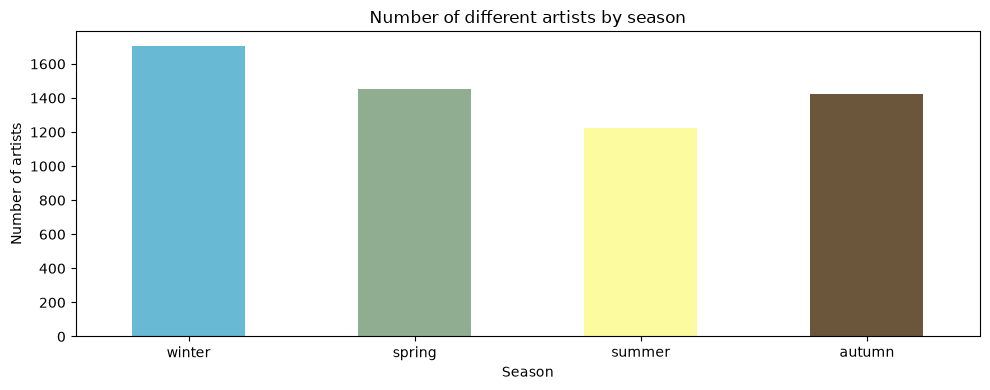

In [10]:
num_of_artists_by_season = pd.read_sql("""
    SELECT season, COUNT(DISTINCT artist) AS number_of_artists
    FROM music
    WHERE year > 2020 AND year < 2026
    GROUP BY season
""", conn)

# Put the seasons in calendar order and give each bar its season colour
num_of_artists_by_season = num_of_artists_by_season.set_index("season").loc[season_order]
season_bar_colors = [season_colors[s] for s in num_of_artists_by_season.index]

ax = num_of_artists_by_season["number_of_artists"].plot(kind="bar", color=season_bar_colors, title="Number of different artists by season", legend=False, figsize=(10, 4))
ax.set_xlabel("Season")
ax.set_ylabel("Number of artists") 
plt.xticks(rotation=0)
plt.tight_layout()
save_chart("q2_artists_by_season")
plt.show()

But the diversity also depends on how much I listened. The chart below shows the number of plays per season.

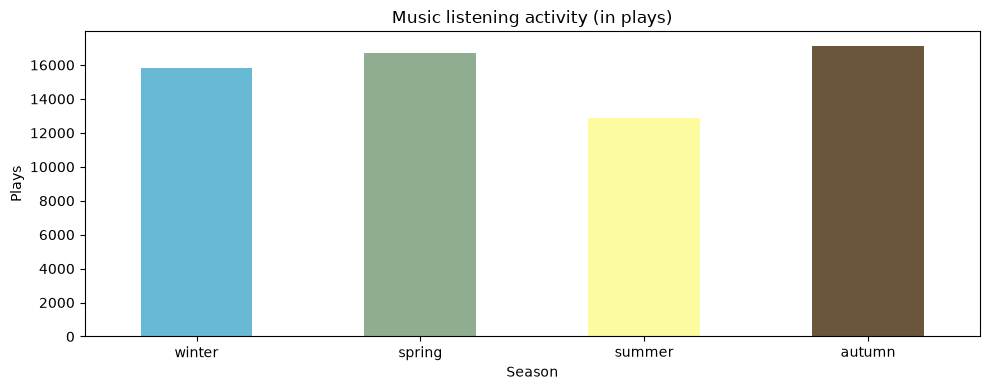

In [11]:
listening_volume_over_seasons = pd.read_sql("""
    SELECT season, COUNT(*) AS plays
    FROM music
    WHERE year > 2020 AND year < 2026
    GROUP BY season
""", conn)


listening_volume_over_seasons = listening_volume_over_seasons.set_index("season").loc[season_order]
season_bar_colors = [season_colors[p] for p in listening_volume_over_seasons.index]

ax = listening_volume_over_seasons["plays"].plot(kind="bar", title="Music listening activity (in plays)",
                        color=season_bar_colors, legend=False, figsize=(10, 4))
ax.set_xlabel("Season")
ax.set_ylabel("Plays")
plt.xticks(rotation=0)
plt.tight_layout()
save_chart("q2_plays_by_season")
plt.show()


To compare the seasons fairly, I combined the two: The number of different artists per 100 plays.

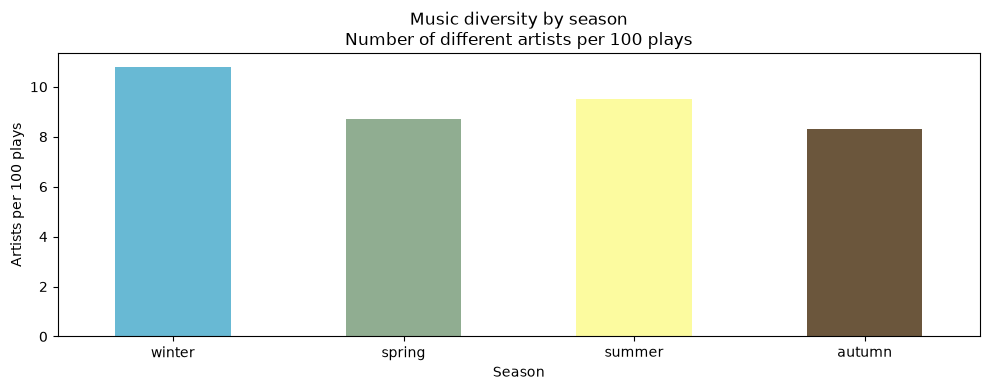

In [12]:
diversity_by_seasons = pd.read_sql("""
    SELECT season,
           COUNT(*) AS plays,
           COUNT(DISTINCT artist) AS artists,
           ROUND(COUNT(DISTINCT artist) * 100.0 / COUNT(*), 1) AS artists_per_100_plays
    FROM music
    WHERE year > 2020 AND year < 2026
    GROUP BY season

""", conn)

diversity_by_seasons = diversity_by_seasons.set_index("season").loc[season_order]
season_bar_colors = [season_colors[p] for p in diversity_by_seasons.index]

ax = diversity_by_seasons["artists_per_100_plays"].plot(kind="bar", title="Music diversity by season\nNumber of different artists per 100 plays",
                        color=season_bar_colors, legend=False, figsize=(10, 4))
ax.set_xlabel("Season")
ax.set_ylabel("Artists per 100 plays")
plt.xticks(rotation=0)
plt.tight_layout()
save_chart("q2_diversity_by_season")
plt.show()

**Takeaway:** Winter is my most diverse season: It has the most different artists and the highest diversity (around 11 artists per 100 plays). Autumn is the least diverse and has the most plays. 

The differences are modest (8-11 artists per 100 plays).

# Question 3
Does my music listening activity look different in semester versus exams?

I look at my first year at university, Sep 2025 - August 2026, and the listening hours per month. The coloured background shows the semester phase.

The same kind of chart is also used for podcasts in Question 5, so I wrapped the drawing code in a function.

In [13]:
def plot_monthly_with_phases(monthly, title, filename):
    """Line chart of monthly listening hours with a coloured background for each semester phase."""
    monthly = monthly.copy()

    # One point per month, placed in the middle of the month (the 15th)
    monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=15))

    # Semester phase of every day in the academic year
    days = pd.DataFrame({"date": pd.date_range("2025-09-01", "2026-08-31")})
    days["phase"] = [semester_phase(d.day, d.month) for d in days["date"]]

    # Group days that follow each other and have the same phase into one period
    days["run"] = (days["phase"] != days["phase"].shift()).cumsum()
    runs = days.groupby("run").agg(start=("date", "min"),
                                   end=("date", "max"),
                                   phase=("phase", "first"))

    fig, ax = plt.subplots(figsize=(11, 4))

    # Coloured background first, the line on top of it
    for _, r in runs.iterrows():
        ax.axvspan(r["start"], r["end"] + pd.Timedelta(days=1),
                   color=phase_colors[r["phase"]], alpha=0.15, linewidth=0)
    ax.plot(monthly["date"], monthly["total_hours"], marker="o", color="black")

    ax.set_xlim(pd.Timestamp("2025-09-01"), pd.Timestamp("2026-09-01"))
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45, ha="right")

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Hours listened")
    handles = [Patch(color=c, alpha=0.3, label=name) for name, c in phase_colors.items()]
    ax.legend(handles=handles, title="Semester phase", loc="upper right")

    plt.tight_layout()
    save_chart(filename)
    plt.show()

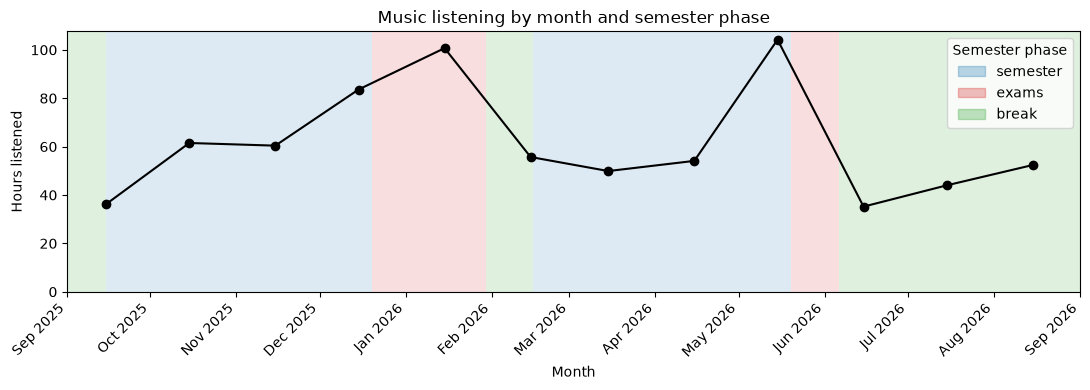

In [14]:
monthly_music = pd.read_sql("""
    SELECT year, month, ROUND(SUM(seconds_played) / 3600.0, 1) AS total_hours
    FROM music
    WHERE (year = 2025 AND month >= 9) OR (year = 2026 AND month <= 8)
    GROUP BY year, month
    ORDER BY year, month
""", conn)

plot_monthly_with_phases(monthly_music, "Music listening by month and semester phase", "q3_music_by_month")

**Takeaway**: My two busiest months, January and May, both contain exam periods. I can't tell the reason from the data; one possibility is background music while studying.

# Question 4
Are there any daily habits in how I listen to podcasts?

The same view as in Question 1, now for podcasts: total listening time for each hour of the day over the whole data set.

In [15]:
podcast_activity = pd.read_sql(""" 
        SELECT hour, ROUND(SUM(seconds_played) / 3600.0, 1) AS total_hours
        FROM podcasts
        GROUP BY hour
        ORDER BY hour
""", conn)

# Hours without any podcast plays are missing from the result, so add them back with 0
# (otherwise the line would connect the neighbouring hours and hide the gap)
podcast_activity = (podcast_activity.set_index("hour")
                    .reindex(range(24), fill_value=0)
                    .reset_index())

ax = podcast_activity.plot(x="hour", y="total_hours", kind="line", title="Daily podcast listening activity by hour of day", legend=False, figsize=(10, 4))
ax.set_xlabel("Hour of the day")
ax.set_ylabel("Total hours")
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.set_ylim(bottom=0)
plt.tight_layout()

# delete '#' to get your results
# save_chart("q1_podcast_daily")

plt.close()        # delete this line to get your results

**Note:** I chose not to publish the chart for this question for privacy reasons.

# Question 5
Does my podcast listening go down in exam season, the summer break or at the start of new semester?

Monthly podcast listening hours in my first year at university (Sep 2025 - Aug 2026), with the semester phases in the background.

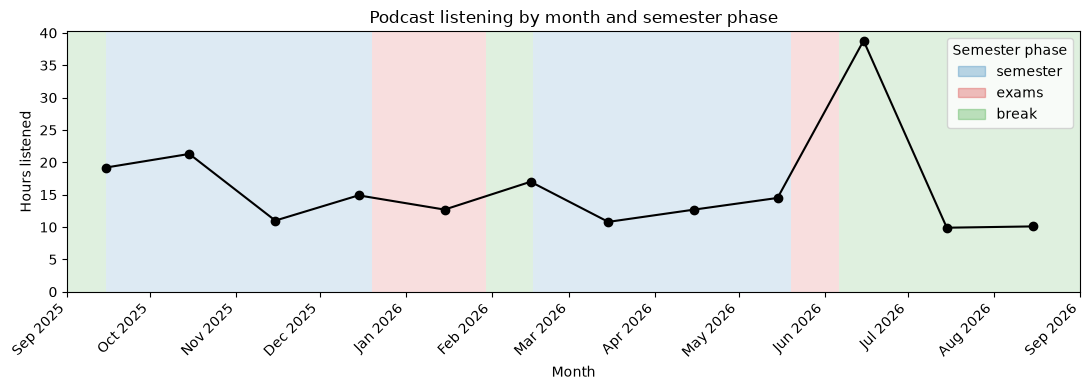

In [16]:



monthly_podcasts = pd.read_sql("""
    SELECT year, month, ROUND(SUM(seconds_played) / 3600.0, 1) AS total_hours
    FROM podcasts
    WHERE (year = 2025 AND month >= 9) OR (year = 2026 AND month <= 8)
    GROUP BY year, month
    ORDER BY year, month
""", conn)

plot_monthly_with_phases(monthly_podcasts, "Podcast listening by month and semester phase", "q5_podcasts_by_month")

**Takeaway:** My podcast listening stays about 11-21 hours per month throughout the semester and exam periods, so unlike my music it does not change during the exams. September and October 2025, the start of new semester, are actually among the highest months. Podcast listening goes down in the summer break. 

The outlier is June, with about 39 hours, the month in which the exams end and the summer break begins. 

# Conclusion
1. **Music during the day:** Not published.
2. **Diversity by season:** Winter is my most varied season and autumn the least, but the differences are modest.
3. **Semester vs. exams:** I listen to about twice as much music in exam months as in semester months.
4. **Podcasts during the day:** Not published.
5. **Podcasts over the year:** Steady during semester and exams, lower in the summer break, with one spike in June.

## Limitations

- The data is from one person's account, so the results say nothing about other listeners.
- The data starts in May 2020 and ends in September 2026. The seasonal analysis therefore uses 2021–2025 only.
- Dates of semester phases correspond to my year 2025/2026.
- Questions 3 and 5 cover only one academic year, so I can't tell whether the patterns repeat. Months that contain two phases blur the comparison.
- Plays shorter than 30 seconds (music) and 3 minutes (podcasts) are excluded. Other thresholds would change the numbers slightly.
- Plays while travelling abroad are shown in Czech time.
- Diversity per 100 plays depends on the number of plays.
